# Hands-On AI for Science, Aug 13 Afternoon: Neural Nets

This notebook is based on the notebook <a href="https://docs.pytorch.org/tutorials/beginner/pytorch_with_examples.html">Learning Pytorch with Examples</a> by <a href="https://github.com/jcjohnson/pytorch-examples">Justin Johnson</a>.  I've basically copied in some of his code examples, and then added extra explanations and plots.




A **neural network** is a complicated function made up of many simple functions, some of which are parameterized.  When the network fails to perform a desired task, you might want to change the network so it does that task better.  **Back-propagation** is the process of analyzing the desired behavior change into a list of desired parameter changes.

Back-propagation is at the heart of the most popular Deep Learning Frameworks like PyTorch and Jax. This allows us to define custom methods as a composite of operations, which can be implemented iteratively using <a href="https://en.wikipedia.org/wiki/Hill_climbing">hill-climbing</a> or <a href="https://en.wikipedia.org/wiki/Gradient_descent">gradient descent</a> in order to modify the behavior of the whole network. 



In [1]:
!pip install -q numpy matplotlib

import a13pm_hw1
import importlib
import numpy as np
import matplotlib.pyplot as plt

1. [Gradient Descent](#gradientdescent)
2. 

### Gradient Descent

<a href="https://commons.wikimedia.org/wiki/File:Gradient_descent.gif">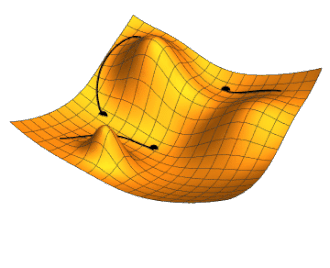</a>

Suppose that a neural network has some parameter $w$, and it observes some input $x$.  Suppose that we can measure how badly the network performs: We call such a measure the <a href="https://en.wikipedia.org/wiki/Loss_function">loss function</a>.  Gradient descent improves the performance of the network by shifting $w$ just a little bit "downhill."  The slope of the function $f(x,w)$ is called its derivative, $\frac{df}{dw}$, so moving downhill means modifying $w$ according to

$$w\leftarrow w-0.001 \frac{df}{dw}$$

(The number 0.001 is called the "learning rate;" 0.001 is not always the best learning rate, but sometimes it is).  

The problem solved by back-propagation is this: Given a complicated function $f(w)$, how do we find its derivative?

### Backpropagation 

The solution proposed by back-propagation is

1. Decompose the complicated function, $f(w)$, into a series of simple functions
2. Compute the derivative $\frac{df}{dw}$ by multiplying together the known derivatives of all of those simple functions.

Neural Networks are just a stack of operations, some of which contain learnable parameters. Our goal is to minimize some loss function w.r.t these learnable parameters. Thus we need to compute the derivative
of our loss w.r.t these parameters so we can perform gradient descent.

### Case Study: Logistic Sigmoid

The sigmoid function is a common method used in Deep Learning to convert raw outputs to probabilities.

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

We can first write the sigmoid function as a compose of simpler ones like:

$$
a = -1 \cdot x
$$

$$
b = e^{a}
$$

$$
c = 1 + b
$$

$$
\sigma(x) = \frac{1}{c}
$$

What we want is the derivative of the output $ \sigma(x) $ w.r.t the input $x$, so we can use the standard <a href="https://en.wikipedia.org/wiki/Chain_rule">chain rule</a>.  George Simmons defined the chain rule thus: "If a car travels twice as fast as a bicycle and the bicycle is four times as fast as a walking man, then the car travels 2 × 4 = 8 times as fast as the man."

Using the same logic,

$$\frac{d\sigma(x)}{dx} = \frac{d\sigma(x)}{dc}\frac{dc}{db}\frac{db}{da}\frac{da}{dx}$$

And each of these derivatives are expressed as:

- $\frac{d\sigma(x)}{dc}$ - Derivative of Division, which you can look up, it is $-\frac{1}{c^2}$
- $\frac{dc}{db}$ - Derivative of Sum, which you can look up, it is $1$
- $\frac{db}{da}$ - Derivative of Exponentiation, which you can look up, it is $e^a$
- $\frac{da}{dx}$ - Derivative of Multiplication, which you can look up, it is $-1$

Putting those all together, we get

$$\frac{d\sigma(x)}{dx} = -\frac{1}{(1+e^{-x})^2}\times 1\times e^{-x} \times -1=\frac{e^{-x}}{(1+e^{-x})^2}$$

That's not a very informative formula, but it's correct; if you plug in any particular value of $x$, this formula will give you the slope $d\sigma/dx$.

So if we can describe these sub operations and their derivatives, then we can chain together their derivatives to get the final derivative automatically. TLDR: Without explicitly defining the derivative of a sigmoid, we can compute the derivative of the smaller operations happening and chain them together!

